# Fase 1: Exploratory Data Analysis (EDA) & Pembersihan Data

## Tujuan
Memahami anatomi data sensor dan maintenance logs, mengidentifikasi pola degradasi, membuang fitur tidak berguna, dan membersihkan data.

## Langkah-langkah
- 1.1: Data Ingestion & Inspeksi Awal (Cek Rasio Imbalanced)
- 1.2: Pembersihan Data & Feature Selection (drop humidity, operating_hours)
- 1.3: Visualisasi Degradasi & Validasi Hukum Fisika (Time-Series Plotting)
- 1.4: Analisis Korelasi (Heatmap Correlation)

In [ ]:
import pandas as pd

# 1.1: Data Ingestion & Inspeksi Awal
df = pd.read_csv('../data/sensor_readings.csv')

# Mengubah tipe data kolom timestamp menjadi format waktu sesungguhnya
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Menjadikan kolom timestamp tersebut sebagai index
df.set_index('timestamp', inplace=True)

# Memastikan kolom index sudah menjadi DatetimeIndex
print("--- Info DataFrame ---")
df.info()

# 1.1b: Menampilkan rasio proporsi mesin rusak dan sehat di kolom target failure
print("\n--- Rasio Proporsi Mesin Rusak vs Sehat ---")
display(df['failure'].value_counts(normalize=True))

In [ ]:
# 1.2a: Melakukan interpolasi linier untuk mengisi nilai kosong (Missing Values)
df.interpolate(method='linear', inplace=True)

# 1.2b: Menghapus (drop) kolom sampah secara permanen
df.drop(columns=['humidity', 'operating_hours'], inplace=True)

# 1.2c: Memvalidasi bahwa sudah tidak ada lagi data yang kosong (NaN)
print("--- Validasi Missing Values (NaN) ---")
print(df.isnull().sum())

# 1.2d: Memvalidasi bahwa kedua kolom sampah sudah benar-benar hilang dari memori
print("\n--- Visualisasi Info Pasca-Pembersihan ---")
df.info()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Mencarimachine_id yang pernah mengalami minimal satu kali kerusakan (failure == 1)
machines_with_failure = df[df['failure'] == 1]['machine_id'].unique()
print(f"Daftar mesin yang pernah rusak: {machines_with_failure}")

# Memilih satu mesin untuk dianalisis (mengambil mesin urutan pertama dari daftar tersebut)
target_machine = machines_with_failure[0]
print(f"\nMenganalisis visualisasi data untuk mesin: {target_machine}")

# 2. Memfilter subset data khusus untuk mesin terpilih
df_machine = df[df['machine_id'] == target_machine]

# Menyimpan kapan terjadinya timestamp kerusakan pada mesin terpilih untuk axvline
failure_times = df_machine[df_machine['failure'] == 1].index

# 3. Membuat kanvas gambar matplotlib dengan 2 subplot yang disusun vertikal (nrows=2)
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15, 10), sharex=True)

# 4. Subplot 1 (Atas): Plot grafik Temperature over time
sns.lineplot(data=df_machine, x=df_machine.index, y='temperature', ax=axes[0], color='orange')
axes[0].set_title(f"Degradasi Suhu (Temperature) Jelang Kerusakan - Mesin {target_machine}", fontsize=14, fontweight='bold')
axes[0].set_ylabel("Suhu (°C)")

# 5. Subplot 2 (Bawah): Plot grafik Vibration over time
sns.lineplot(data=df_machine, x=df_machine.index, y='vibration', ax=axes[1], color='dodgerblue')
axes[1].set_title(f"Degradasi Getaran (Vibration) Jelang Kerusakan - Mesin {target_machine}", fontsize=14, fontweight='bold')
axes[1].set_ylabel("Getaran")
axes[1].set_xlabel("Waktu (Timestamp)")

# 6. Menambahkan garis vertikal tebal berwarna MERAH saat `failure == 1` di kedua subplot
for fail_time in failure_times:
    axes[0].axvline(x=fail_time, color='red', linestyle='--', linewidth=2.5, label='Mesin Rusak (Failure = 1)')
    axes[1].axvline(x=fail_time, color='red', linestyle='--', linewidth=2.5, label='Mesin Rusak (Failure = 1)')

# Merapikan tampilan legenda agar tidak menumpuk
axes[0].legend(loc='upper right')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

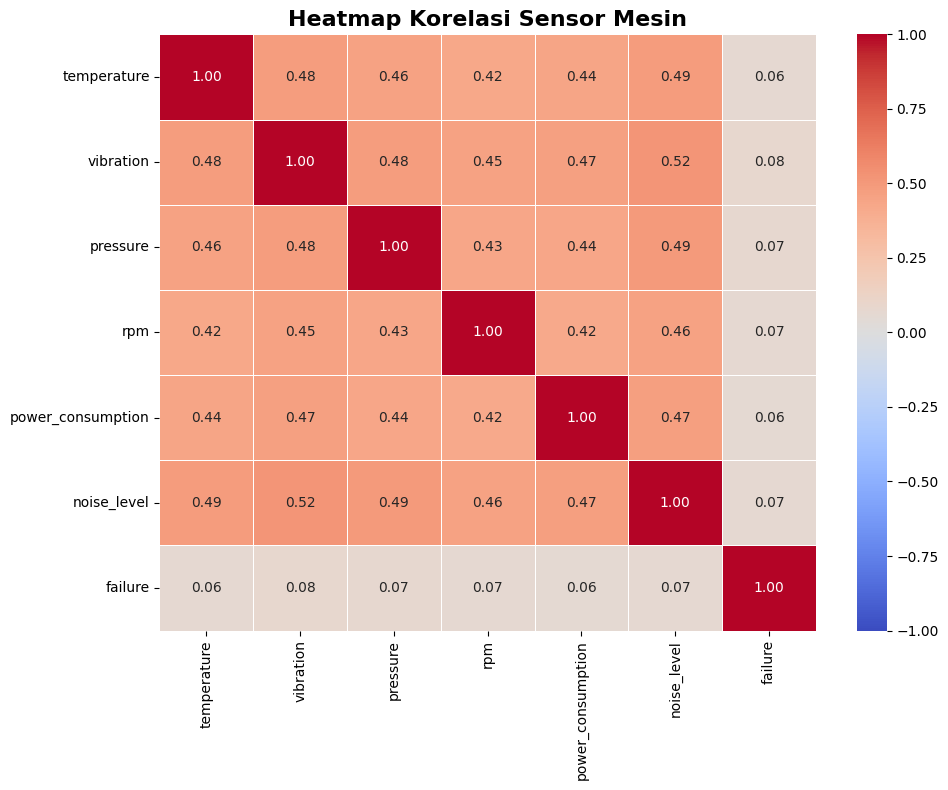

In [7]:
# 1. Memilih hanya kolom yang bernilai numerik (mengecualikan kolom seperti machine_id)
numeric_cols = df.select_dtypes(include=['number'])

# Menghitung matriks korelasi antar sensor numerik
corr_matrix = numeric_cols.corr()

# 2 & 3. Membuat visualisasi Heatmap Correlation dengan seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)

# Memberikan judul plot yang informatif
plt.title("Heatmap Korelasi Sensor Mesin", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()